# Decision Tree — Student Placement Prediction

In this module, we will build a Decision Tree Classification model
using a real-world-style college student placement dataset.

Our goal is to predict whether a student will get placed based
on factors related to their academic performance, skills,
experience, and other student attributes.

## Machine Learning Problem

Input:

Student-related features

Output:

Placement Status

0 → Not Placed
1 → Placed

## We will cover

1. Dataset loading
2. Data exploration
3. Data cleaning
4. Exploratory Data Analysis
5. Feature preparation
6. Train/Test Split
7. Decision Tree training
8. Tree visualization
9. Predictions
10. Confusion Matrix
11. Accuracy, Precision, Recall and F1
12. Feature Importance
13. Tree Depth and Overfitting
14. Testing with new student data

#Install Kaggle

In [1]:
!pip install -q kaggle

#Import Libraries

In [2]:
import os
from getpass import getpass

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


### Kaggle API Authentication

We will use `getpass()` to securely enter the Kaggle API token.

The token will not be displayed while entering it.

In [3]:
kaggle_token = getpass("Enter your Kaggle API token: ")

os.environ["KAGGLE_API_TOKEN"] = kaggle_token

del kaggle_token

print("Kaggle API token configured successfully.")

Enter your Kaggle API token: ··········
Kaggle API token configured successfully.


## Download Dataset

Kaggle Dataset:

`sahilislam007/college-student-placement-factors-dataset`

We will download and extract the dataset directly into Google Colab.

In [4]:
!mkdir -p /content/student_placement_dataset

!kaggle datasets download \
    -d sahilislam007/college-student-placement-factors-dataset \
    -p /content/student_placement_dataset \
    --unzip

Dataset URL: https://www.kaggle.com/datasets/sahilislam007/college-student-placement-factors-dataset
License(s): MIT
100% 108k/108k [00:00<00:00, 74.4MB/s]



#Check Downloaded Files

In [5]:
os.listdir("/content/student_placement_dataset")

['college_student_placement_dataset.csv']

#Find CSV Files

In [6]:
csv_files = [
    file
    for file in os.listdir("/content/student_placement_dataset")
    if file.lower().endswith(".csv")
]

csv_files

['college_student_placement_dataset.csv']

#Load Dataset

In [7]:
dataset_path = os.path.join(
    "/content/student_placement_dataset",
    csv_files[0]
)

df = pd.read_csv(dataset_path)

df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


#Dataset Shape

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 10000
Columns: 10


#View Column Names

In [9]:
print("Columns:\n")

for column in df.columns:
    print(column)

Columns:

College_ID
IQ
Prev_Sem_Result
CGPA
Academic_Performance
Internship_Experience
Extra_Curricular_Score
Communication_Skills
Projects_Completed
Placement


#Dataset Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB


#Statistical Summary

In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
College_ID,10000,100,CLG0062,133,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IQ,10000.0,NaN,NaN,NaN,99.4718,15.053101,41.0,89.0,99.0,110.0,158.0
Prev_Sem_Result,10000.0,NaN,NaN,NaN,7.535673,1.447519,5.0,6.29,7.56,8.79,10.0
CGPA,10000.0,NaN,NaN,NaN,7.532379,1.470141,4.54,6.29,7.55,8.77,10.46
Academic_Performance,10000.0,NaN,NaN,NaN,5.5464,2.873477,1.0,3.0,6.0,8.0,10.0
Internship_Experience,10000,2,No,6036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extra_Curricular_Score,10000.0,NaN,NaN,NaN,4.9709,3.160103,0.0,2.0,5.0,8.0,10.0
Communication_Skills,10000.0,NaN,NaN,NaN,5.5618,2.900866,1.0,3.0,6.0,8.0,10.0
Projects_Completed,10000.0,NaN,NaN,NaN,2.5134,1.715959,0.0,1.0,3.0,4.0,5.0
Placement,10000,2,No,8341,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#Check Missing Values

## Missing Values

Before training the model, we need to identify missing values.

We will check the number and percentage of missing values in each column.

In [12]:
missing_values = df.isnull().sum()

missing_values = missing_values.sort_values(
    ascending=False
)

missing_values

,0
College_ID,0
IQ,0
Prev_Sem_Result,0
CGPA,0
Academic_Performance,0
Internship_Experience,0
Extra_Curricular_Score,0
Communication_Skills,0
Projects_Completed,0
Placement,0


In [13]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage

,0
College_ID,0.0
IQ,0.0
Prev_Sem_Result,0.0
CGPA,0.0
Academic_Performance,0.0
Internship_Experience,0.0
Extra_Curricular_Score,0.0
Communication_Skills,0.0
Projects_Completed,0.0
Placement,0.0


#Visualize Missing Values

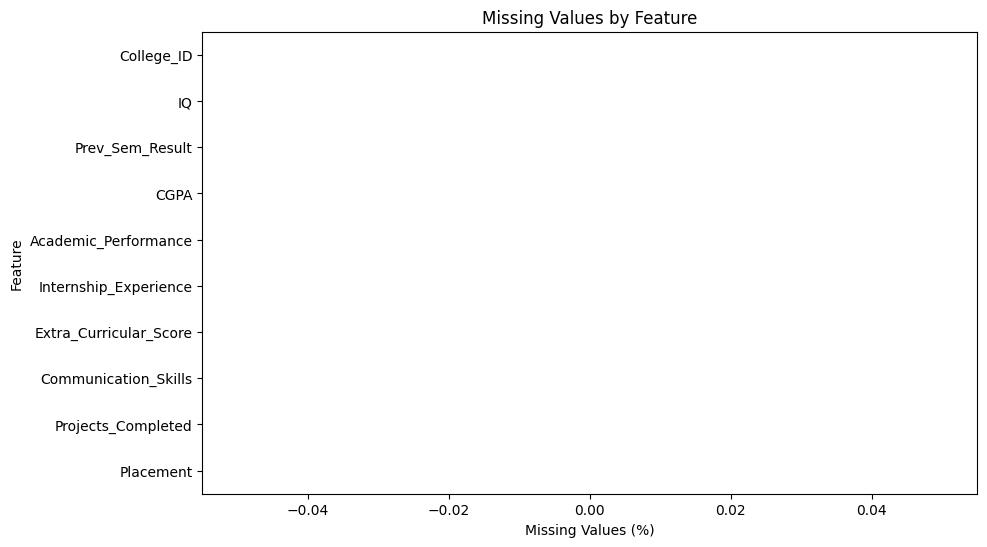

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Missing Values by Feature")

plt.show()

#Check Duplicate Rows

In [15]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


#Identify Target Column

# Target Variable

Our objective is to predict student placement.

The target column represents whether the student was placed or not.

This is a binary classification problem:

0 → Not Placed

1 → Placed

Before continuing, inspect the actual target column name in the dataset.

In [16]:
df.columns.tolist()

['College_ID',
 'IQ',
 'Prev_Sem_Result',
 'CGPA',
 'Academic_Performance',
 'Internship_Experience',
 'Extra_Curricular_Score',
 'Communication_Skills',
 'Projects_Completed',
 'Placement']

#Inspect Target Distribution

In [17]:
df["Placement"].value_counts()

,count
Placement,
No,8341
Yes,1659


#Target Visualization

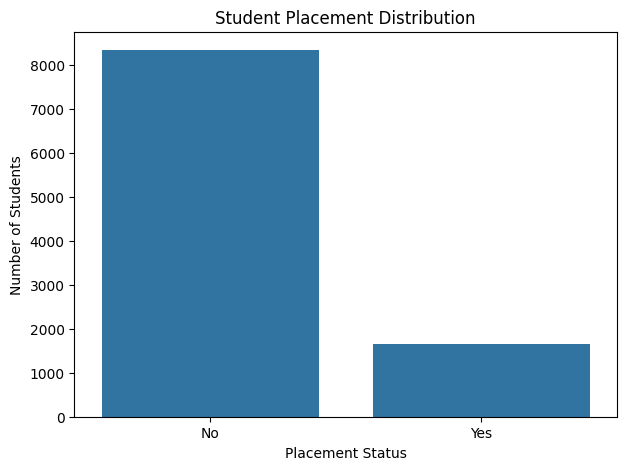

In [18]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Placement"
)

plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.title("Student Placement Distribution")

plt.show()

#Target Percentage

In [19]:
placement_percentage = (
    df["Placement"]
    .value_counts(normalize=True)
    .mul(100)
)

placement_percentage

,proportion
Placement,
No,83.41
Yes,16.59


#Numerical Features

In [20]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical Features:")

for column in numeric_columns:
    print(column)

Numerical Features:
IQ
Prev_Sem_Result
CGPA
Academic_Performance
Extra_Curricular_Score
Communication_Skills
Projects_Completed


#Categorical Features

In [21]:
categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical Features:")

for column in categorical_columns:
    print(column)

Categorical Features:
College_ID
Internship_Experience
Placement


#Correlation Analysis

# Feature Correlation

Correlation helps us understand relationships between numerical variables.

We will visualize the numerical feature correlations before preparing
the data for the Decision Tree.

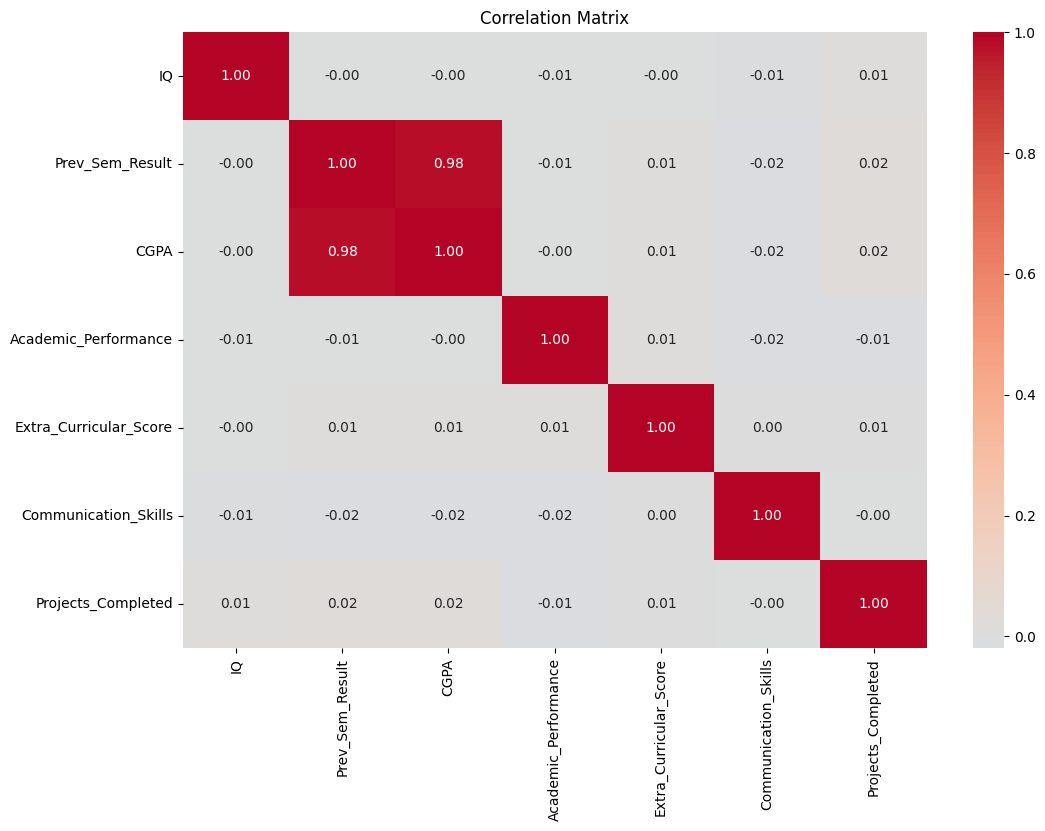

In [22]:
plt.figure(figsize=(12, 8))

correlation_matrix = df.corr(
    numeric_only=True
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

#Placement vs Numerical Features

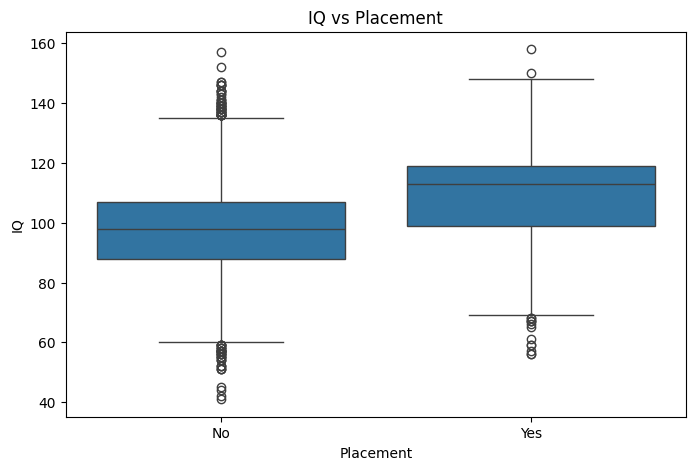

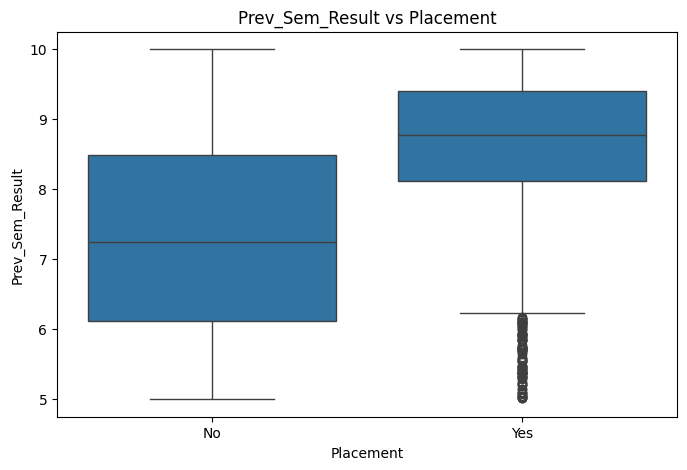

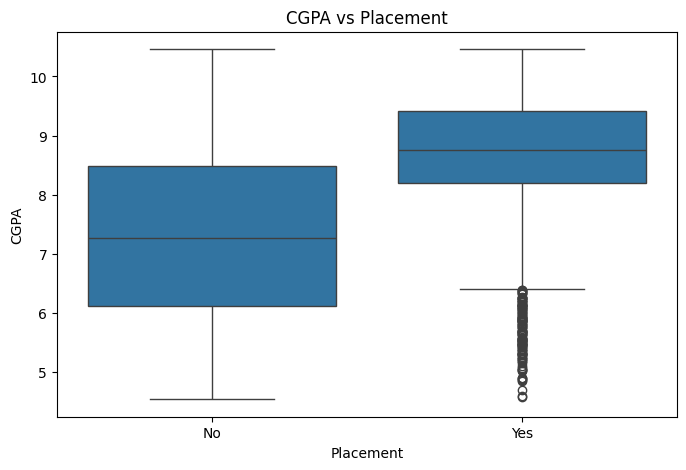

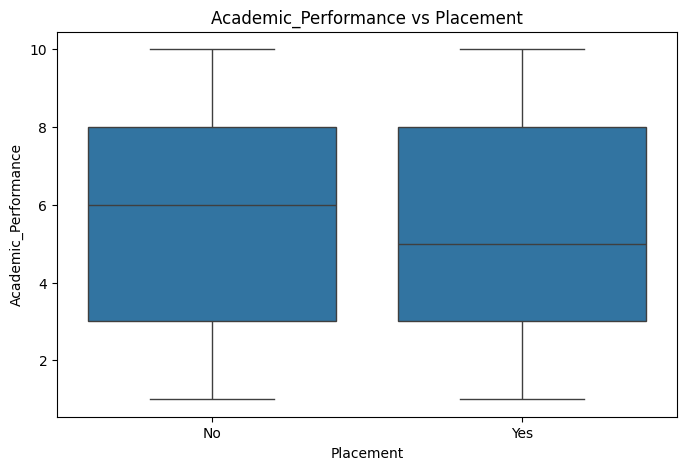

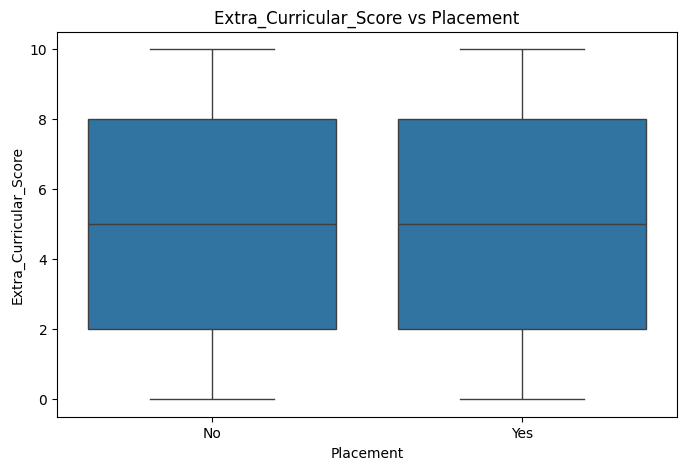

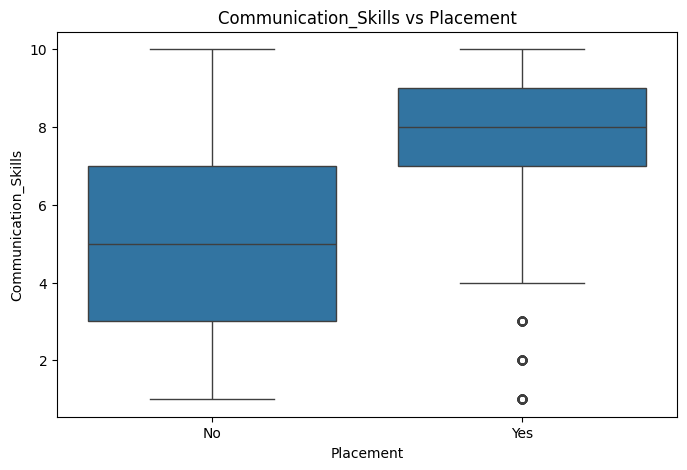

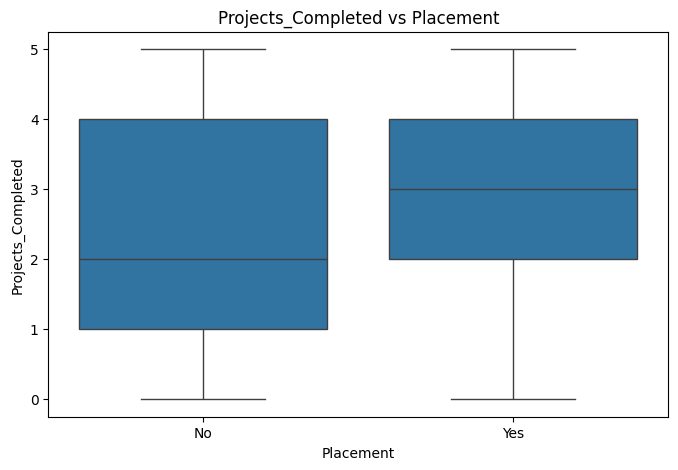

In [23]:
for column in numeric_columns:

    if column != "Placement":

        plt.figure(figsize=(8, 5))

        sns.boxplot(
            data=df,
            x="Placement",
            y=column
        )

        plt.title(
            f"{column} vs Placement"
        )

        plt.show()

#Prepare the Dataset

# Data Preparation

Decision Trees can work with numerical data directly.

For categorical features, we need to convert categories into numerical
representations before passing them to scikit-learn's Decision Tree.

We will:

1. Separate X and y
2. Encode categorical variables
3. Handle missing values
4. Create training and testing datasets

#Create a Copy

In [24]:
df_model = df.copy()

print(
    "Original shape:",
    df_model.shape
)

Original shape: (10000, 10)


#Handle Missing Values

In [25]:
for column in df_model.columns:

    if df_model[column].dtype == "object":

        df_model[column] = df_model[column].fillna(
            df_model[column].mode()[0]
        )

    else:

        df_model[column] = df_model[column].fillna(
            df_model[column].median()
        )

print(
    "Total missing values:",
    df_model.isnull().sum().sum()
)

Total missing values: 0


#Encode Target

In [26]:
print(
    df_model["Placement"].unique()
)

['No' 'Yes']


In [27]:
if df_model["Placement"].dtype == "object":

    df_model["Placement"] = (
        df_model["Placement"]
        .map({
            "Yes": 1,
            "No": 0
        })
    )

df_model["Placement"].value_counts()

,count
Placement,
0,8341
1,1659


#Separate Features and Target

In [28]:
X = df_model.drop(
    columns=["Placement"]
)

y = df_model["Placement"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 9)
y shape: (10000,)


## One-Hot Encoding

Decision Trees in scikit-learn require numerical input.

For categorical variables such as:

Gender:

Male
Female

we can create numerical columns such as:

Gender_Male
Gender_Female

This is called One-Hot Encoding.

In [29]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("New X shape:", X.shape)

X.head()

New X shape: (10000, 107)


,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,College_ID_CLG0002,College_ID_CLG0003,College_ID_CLG0004,...,College_ID_CLG0092,College_ID_CLG0093,College_ID_CLG0094,College_ID_CLG0095,College_ID_CLG0096,College_ID_CLG0097,College_ID_CLG0098,College_ID_CLG0099,College_ID_CLG0100,Internship_Experience_Yes
0,107,6.61,6.28,8,8,8,4,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,97,5.52,5.37,8,7,8,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,109,5.36,5.83,9,3,1,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,122,5.47,5.75,6,1,6,1,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,96,7.91,7.69,7,8,10,2,False,False,True,...,False,False,False,False,False,False,False,False,False,False


#Check Final Dataset

In [30]:
print("=" * 50)
print("FINAL DATASET CHECK")
print("=" * 50)

print("Rows:", X.shape[0])
print("Features:", X.shape[1])
print("Missing values:", X.isnull().sum().sum())
print("Target classes:", sorted(y.unique()))

print("\nTarget distribution:")
print(y.value_counts())

print("=" * 50)

FINAL DATASET CHECK
Rows: 10000
Features: 107
Missing values: 0
Target classes: [np.int64(0), np.int64(1)]

Target distribution:
Placement
0    8341
1    1659
Name: count, dtype: int64


#Final Feature List

In [31]:
print("Features used by the Decision Tree:\n")

for feature in X.columns:
    print(feature)

Features used by the Decision Tree:

IQ
Prev_Sem_Result
CGPA
Academic_Performance
Extra_Curricular_Score
Communication_Skills
Projects_Completed
College_ID_CLG0002
College_ID_CLG0003
College_ID_CLG0004
College_ID_CLG0005
College_ID_CLG0006
College_ID_CLG0007
College_ID_CLG0008
College_ID_CLG0009
College_ID_CLG0010
College_ID_CLG0011
College_ID_CLG0012
College_ID_CLG0013
College_ID_CLG0014
College_ID_CLG0015
College_ID_CLG0016
College_ID_CLG0017
College_ID_CLG0018
College_ID_CLG0019
College_ID_CLG0020
College_ID_CLG0021
College_ID_CLG0022
College_ID_CLG0023
College_ID_CLG0024
College_ID_CLG0025
College_ID_CLG0026
College_ID_CLG0027
College_ID_CLG0028
College_ID_CLG0029
College_ID_CLG0030
College_ID_CLG0031
College_ID_CLG0032
College_ID_CLG0033
College_ID_CLG0034
College_ID_CLG0035
College_ID_CLG0036
College_ID_CLG0037
College_ID_CLG0038
College_ID_CLG0039
College_ID_CLG0040
College_ID_CLG0041
College_ID_CLG0042
College_ID_CLG0043
College_ID_CLG0044
College_ID_CLG0045
College_ID_CLG0046


# Part 1 Complete

We have:

- Downloaded the Kaggle dataset
- Loaded it into Pandas
- Inspected the dataset
- Checked missing values
- Checked duplicates
- Explored the target variable
- Visualized placement distribution
- Analyzed numerical features
- Checked correlations
- Handled missing values
- Encoded the target
- Encoded categorical features
- Created X and y

Our Machine Learning problem is now:

Student Features

↓

Decision Tree

↓

Placement Prediction

0 → Not Placed

1 → Placed

Next:

Train/Test Split → Decision Tree Training → Predictions → Tree Visualization

# Part 1 Complete

We have:

- Downloaded the Kaggle dataset
- Loaded it into Pandas
- Inspected the dataset
- Checked missing values
- Checked duplicates
- Explored the target variable
- Visualized placement distribution
- Analyzed numerical features
- Checked correlations
- Handled missing values
- Encoded the target
- Encoded categorical features
- Created X and y

Our Machine Learning problem is now:

Student Features

↓

Decision Tree

↓

Placement Prediction

0 → Not Placed

1 → Placed

Next:

Train/Test Split → Decision Tree Training → Predictions → Tree Visualization

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 8000
Testing samples: 2000


#Check Class Distribution

In [33]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
Placement
0    0.834125
1    0.165875
Name: proportion, dtype: float64

Testing distribution:
Placement
0    0.834
1    0.166
Name: proportion, dtype: float64


#Create the Decision Tree

# Decision Tree Classifier

A Decision Tree learns a sequence of questions that splits the data
into increasingly homogeneous groups.

For example:

CGPA > 7.5?

├── Yes → Projects > 2?

│         ├── Yes → Placed
│         └── No  → ...

└── No → Not Placed

The tree automatically learns these decision rules from the training data.

In [34]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

print(decision_tree)

DecisionTreeClassifier(random_state=42)


#Train the Model

In [35]:
decision_tree.fit(
    X_train,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


#Check Tree Depth

## Tree Depth

Tree depth represents how many levels of decisions the tree contains.

A very deep tree can learn extremely specific patterns from the training data
and may overfit.

A shallow tree may be too simple and underfit.

We will inspect the automatically generated tree before controlling its depth.

In [36]:
print("Tree depth:", decision_tree.get_depth())

Tree depth: 4


#Number of Leaves

In [37]:
print("Number of leaves:", decision_tree.get_n_leaves())

Number of leaves: 10


#Number of Nodes

In [38]:
print("Total nodes:", decision_tree.tree_.node_count)

Total nodes: 19


# Predictions

The trained Decision Tree can now classify students from the test dataset.

The model follows the learned decision rules from the root node
until it reaches a leaf node.

The leaf contains the final prediction.

In [39]:
y_pred = decision_tree.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0]


#Predict Probabilities

In [40]:
y_prob = decision_tree.predict_proba(X_test)

print(y_prob[:10])

[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]]


#Probability of Placement

In [41]:
placement_probability = y_prob[:, 1]

print("Probability of Placement:")
print(placement_probability[:20])

Probability of Placement:
[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


#Actual vs Predicted

In [42]:
results = pd.DataFrame({
    "Actual Placement": y_test.values,
    "Predicted Placement": y_pred,
    "Placement Probability": placement_probability
})

results.head(20)

,Actual Placement,Predicted Placement,Placement Probability
0,0,0,0.0
1,0,0,0.0
2,0,0,0.0
3,0,0,0.0
4,0,0,0.0
5,0,0,0.0
6,0,0,0.0
7,1,1,1.0
8,0,0,0.0
9,0,0,0.0


#Check Incorrect Predictions

In [43]:
results["Correct"] = (
    results["Actual Placement"] ==
    results["Predicted Placement"]
)

results.head(20)

,Actual Placement,Predicted Placement,Placement Probability,Correct
0,0,0,0.0,True
1,0,0,0.0,True
2,0,0,0.0,True
3,0,0,0.0,True
4,0,0,0.0,True
5,0,0,0.0,True
6,0,0,0.0,True
7,1,1,1.0,True
8,0,0,0.0,True
9,0,0,0.0,True


In [44]:
incorrect_predictions = results[
    results["Correct"] == False
]

print(
    "Incorrect predictions:",
    len(incorrect_predictions)
)

incorrect_predictions.head(20)

Incorrect predictions: 0


,Actual Placement,Predicted Placement,Placement Probability,Correct


#Visualize the Decision Tree

# Visualizing the Decision Tree

Each node contains information such as:

- Feature used for splitting
- Threshold
- Gini impurity
- Number of samples
- Class distribution
- Predicted class

The tree can become very large if it is allowed to grow without restrictions.

For learning purposes, we will initially visualize only the first few levels.

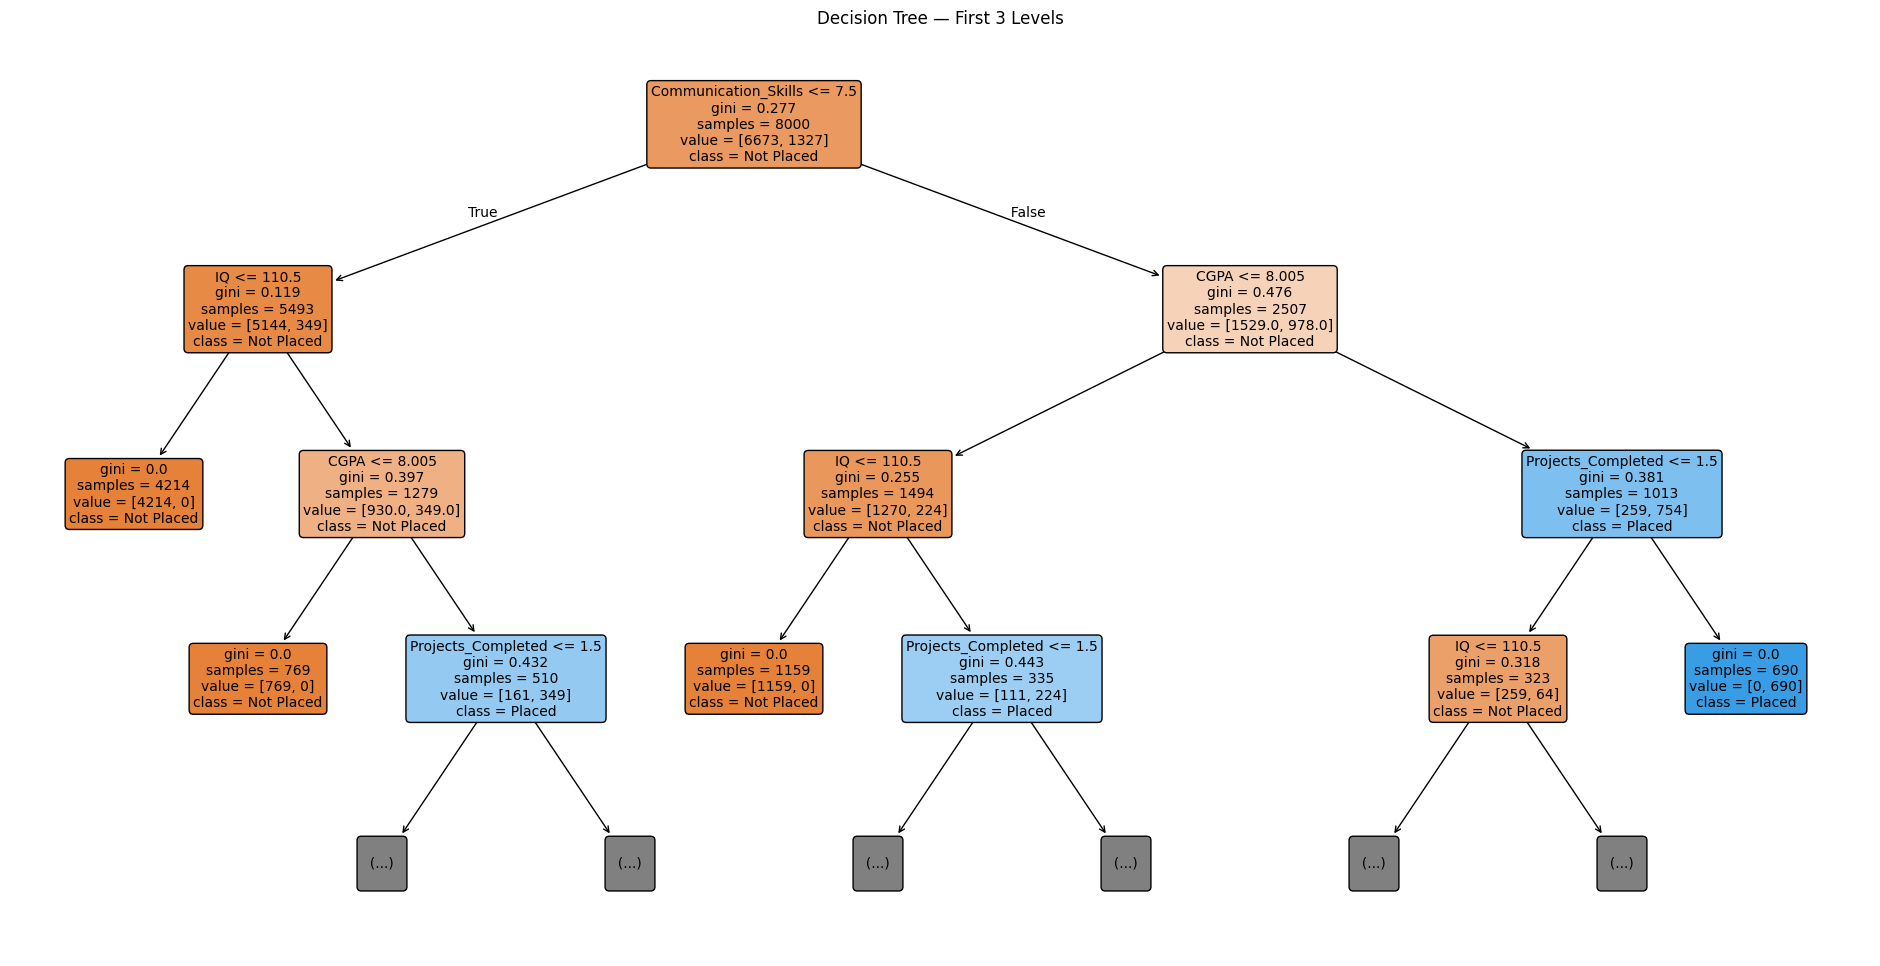

In [45]:
plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree,
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=10
)

plt.title("Decision Tree — First 3 Levels")

plt.show()

# Understanding a Decision Tree Node

A typical node may contain:

Feature <= Threshold

gini = ...

samples = ...

value = [Class 0, Class 1]

class = ...

For example:

CGPA <= 7.5

means the tree is asking:

"Is the student's CGPA less than or equal to 7.5?"

The answer determines which branch the student follows.

#Visualize the First Decision

In [46]:
tree_ = decision_tree.tree_

root_feature_index = tree_.feature[0]
root_threshold = tree_.threshold[0]

root_feature = X.columns[root_feature_index]

print("Root Feature:", root_feature)
print("Root Threshold:", root_threshold)

Root Feature: Communication_Skills
Root Threshold: 7.5


The root node is the first decision made by the tree.

For example, if the result is:

Feature = CGPA

Threshold = 7.5

the first question becomes:

**Is CGPA <= 7.5?**

The actual feature and threshold are learned from this training dataset.

#Feature Importance

In [ ]:
# Feature Importance

Decision Trees can estimate how useful each feature was for splitting the data.

A higher importance means that the feature contributed more to reducing
impurity across the tree.

Feature importance values sum to approximately 1.

In [47]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,CGPA,0.322413
6,Projects_Completed,0.294391
0,IQ,0.217340
5,Communication_Skills,0.165856
1,Prev_Sem_Result,0.000000
...,...,...
102,College_ID_CLG0097,0.000000
103,College_ID_CLG0098,0.000000
104,College_ID_CLG0099,0.000000
105,College_ID_CLG0100,0.000000


#Feature Importance Visualization

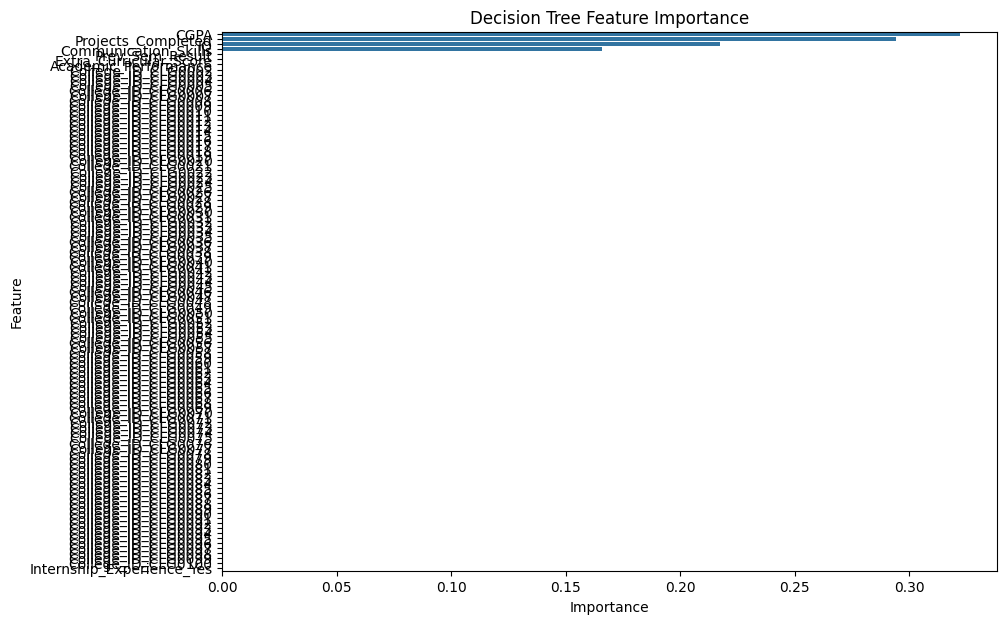

In [48]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")

plt.show()

#Top Features

In [49]:
top_features = feature_importance.head(5)

top_features

,Feature,Importance
2,CGPA,0.322413
6,Projects_Completed,0.294391
0,IQ,0.217340
5,Communication_Skills,0.165856
1,Prev_Sem_Result,0.000000


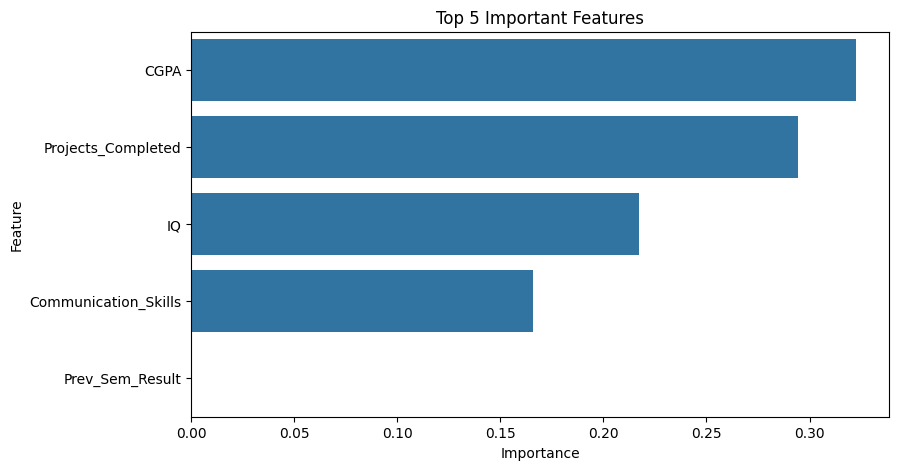

In [50]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 5 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

#Training Predictions

In [51]:
y_train_pred = decision_tree.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

print(
    f"Training Accuracy: {train_accuracy:.4f}"
)

Training Accuracy: 1.0000


#Testing Accuracy

In [52]:
test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Testing Accuracy: {test_accuracy:.4f}"
)

Testing Accuracy: 1.0000


#Compare Training vs Testing Accuracy

In [53]:
accuracy_comparison = pd.DataFrame({
    "Dataset": [
        "Training",
        "Testing"
    ],
    "Accuracy": [
        train_accuracy,
        test_accuracy
    ]
})

accuracy_comparison

,Dataset,Accuracy
0,Training,1.0
1,Testing,1.0


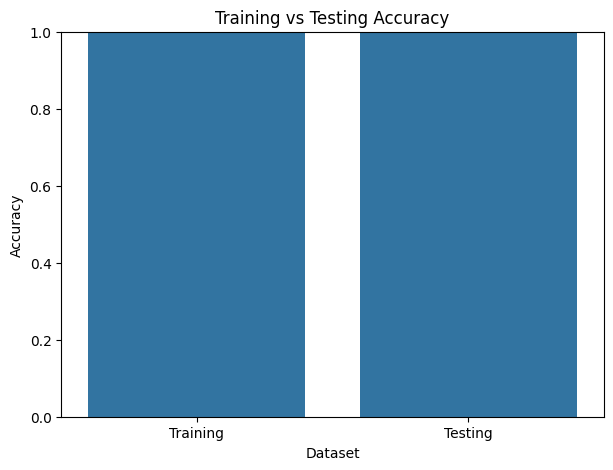

In [54]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=accuracy_comparison,
    x="Dataset",
    y="Accuracy"
)

plt.ylim(0, 1)
plt.title("Training vs Testing Accuracy")
plt.ylabel("Accuracy")

plt.show()

#Check for Overfitting

# Overfitting Check

If the Decision Tree performs extremely well on training data but
significantly worse on testing data, it may be overfitting.

For example:

Training Accuracy → 100%

Testing Accuracy → 75%

This suggests that the tree may have learned very specific patterns
from the training data that do not generalize well.

We will control this in the next section using hyperparameters such as:

- max_depth
- min_samples_split
- min_samples_leaf

#Inspect Tree Complexity

In [55]:
print("Tree Depth :", decision_tree.get_depth())
print("Leaf Nodes :", decision_tree.get_n_leaves())
print("Total Nodes:", decision_tree.tree_.node_count)

Tree Depth : 4
Leaf Nodes : 10
Total Nodes: 19


#Prediction Function

In [56]:
def predict_placement(student_data):

    student_df = pd.DataFrame(
        student_data,
        columns=X.columns
    )

    prediction = decision_tree.predict(
        student_df
    )[0]

    probability = decision_tree.predict_proba(
        student_df
    )[0, 1]

    return prediction, probability

#Test the Function Using an Existing Student

In [57]:
sample_student = X_test.iloc[[0]]

prediction, probability = predict_placement(
    sample_student.values
)

print("Predicted Placement:", prediction)
print(
    f"Placement Probability: {probability:.2%}"
)

Predicted Placement: 0
Placement Probability: 0.00%


#Compare With Actual Result

In [58]:
actual = y_test.iloc[0]

print("Actual Placement:", actual)
print("Predicted Placement:", prediction)
print(
    f"Placement Probability: {probability:.2%}"
)

Actual Placement: 0
Predicted Placement: 0
Placement Probability: 0.00%


#Test Multiple Students

In [59]:
sample_students = X_test.iloc[:10]

sample_predictions = decision_tree.predict(
    sample_students
)

sample_probabilities = decision_tree.predict_proba(
    sample_students
)[:, 1]

sample_results = sample_students.copy()

sample_results["Actual Placement"] = y_test.iloc[:10].values
sample_results["Predicted Placement"] = sample_predictions
sample_results["Placement Probability"] = sample_probabilities

sample_results

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed,College_ID_CLG0002,College_ID_CLG0003,College_ID_CLG0004,...,College_ID_CLG0095,College_ID_CLG0096,College_ID_CLG0097,College_ID_CLG0098,College_ID_CLG0099,College_ID_CLG0100,Internship_Experience_Yes,Actual Placement,Predicted Placement,Placement Probability
2208,95,5.11,5.59,2,1,3,5,False,False,False,...,False,False,False,False,False,False,False,0,0,0.0
3893,71,8.82,8.74,5,0,3,1,False,False,False,...,False,False,False,False,False,False,True,0,0,0.0
9061,100,5.23,4.91,2,5,1,2,False,False,False,...,False,False,False,False,False,False,False,0,0,0.0
5645,73,6.07,5.95,7,10,10,3,False,False,False,...,False,False,False,False,False,False,True,0,0,0.0
4607,107,7.04,6.60,3,9,7,5,False,False,False,...,False,False,False,False,False,False,False,0,0,0.0
823,94,5.84,6.16,10,0,8,5,False,False,False,...,False,False,False,False,False,False,False,0,0,0.0
1760,124,7.73,7.96,3,8,3,1,False,False,False,...,False,False,False,False,False,False,False,0,0,0.0
893,117,6.78,7.13,3,5,9,5,False,False,False,...,False,False,False,False,False,False,True,1,1,1.0
7855,87,8.83,8.91,4,6,5,4,False,False,False,...,False,False,False,False,False,False,True,0,0,0.0
5028,119,5.62,6.05,7,5,3,1,False,False,False,...,False,False,False,False,False,False,True,0,0,0.0


# Part 2 Complete

We have now:

- Split the dataset into training and testing data.
- Trained a Decision Tree Classifier.
- Generated class predictions.
- Generated placement probabilities.
- Visualized the first levels of the tree.
- Identified the root decision.
- Examined tree depth and number of leaves.
- Calculated feature importance.
- Compared training and testing accuracy.
- Created a reusable prediction function.
- Tested predictions on unseen students.

## Current Workflow

Student Data
↓
Train/Test Split
↓
Decision Tree
↓
Learn Decision Rules
↓
Root → Decision Nodes → Branches → Leaf
↓
Placement Prediction

Next we will properly evaluate the model using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report

Then we'll control **tree depth and other hyperparameters** to demonstrate and reduce overfitting.

#Evaluation, Visualization & Overfitting

# Accuracy

Accuracy tells us the percentage of students that were classified correctly.

Accuracy = Correct Predictions / Total Predictions

In [60]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 1.0000
Accuracy: 100.00%


# Precision

Precision answers:

"Of all students predicted as Placed, how many were actually placed?"

Precision = TP / (TP + FP)

In [61]:
precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"Precision: {precision:.4f}")

Precision: 1.0000


# Recall

Recall answers:

"Of all students who were actually placed, how many did the model correctly identify?"

Recall = TP / (TP + FN)

In [62]:
# Recall



"Of all students who were actually placed, how many did the model correctly identify?"

Recall = TP / (TP + FN)

SyntaxError: invalid syntax (1404353501.py, line 3)

# F1 Score

F1 Score combines Precision and Recall.

F1 = 2 × (Precision × Recall) / (Precision + Recall)

A higher F1 Score indicates a better balance between precision and recall.

In [63]:
f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 1.0000


#Classification Report

In [64]:
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1668
           1       1.00      1.00      1.00       332

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



#Compare All Metrics

In [69]:
metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        f1
    ]
})

metrics

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,F1 Score,1.0


#Visualize Model Performance

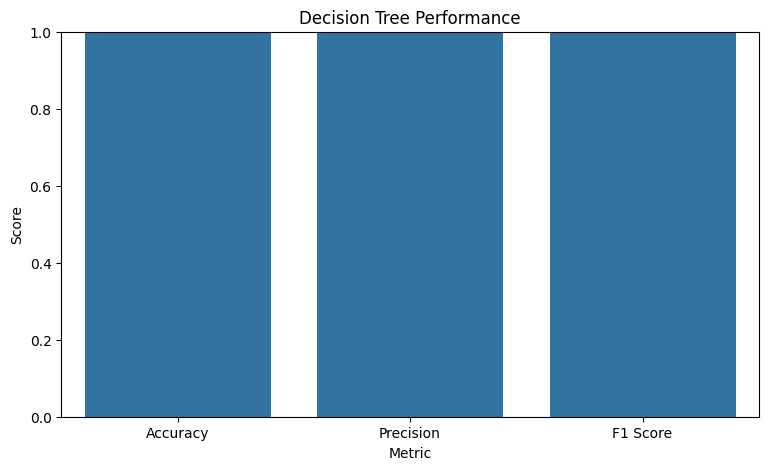

In [70]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=metrics,
    x="Metric",
    y="Score"
)

plt.ylim(0, 1)

plt.title("Decision Tree Performance")
plt.ylabel("Score")
plt.xlabel("Metric")

plt.show()

# Confusion Matrix

A confusion matrix shows exactly how the model classified the students.

                Predicted
              0          1

Actual 0     TN         FP

Actual 1     FN         TP

TN → Correctly predicted Not Placed

FP → Predicted Placed but actually Not Placed

FN → Predicted Not Placed but actually Placed

TP → Correctly predicted Placed

In [71]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1668    0]
 [   0  332]]


#Visualize Confusion Matrix

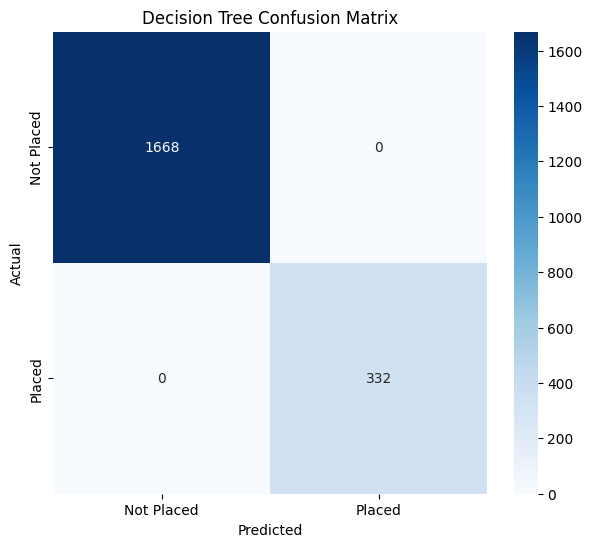

In [72]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

#Training vs Testing Performance

In [73]:
y_train_pred = decision_tree.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    y_train_pred
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

Training Accuracy: 1.0000
Testing Accuracy : 1.0000


In [74]:
print("=" * 60)
print("DECISION TREE — FINAL SUMMARY")
print("=" * 60)

print("Model: DecisionTreeClassifier")
print("Max Depth:", controlled_tree.get_depth())
print("Number of Leaves:", controlled_tree.get_n_leaves())

print("\nPerformance:")
print(f"Accuracy : {controlled_accuracy:.4f}")
print(f"Precision: {controlled_precision:.4f}")
print(f"Recall   : {controlled_recall:.4f}")
print(f"F1 Score : {controlled_f1:.4f}")

print("\nTop Features:")

for _, row in controlled_importance.head(5).iterrows():
    print(
        f"{row['Feature']}: "
        f"{row['Importance']:.4f}"
    )

print("=" * 60)

DECISION TREE — FINAL SUMMARY
Model: DecisionTreeClassifier


NameError: name 'controlled_tree' is not defined

# Conclusion

In this module, we built a complete Decision Tree Classification model
using a real-world college student placement dataset.

We followed the complete Machine Learning workflow:

1. Loaded the dataset using the Kaggle API.
2. Explored the dataset using Pandas.
3. Checked data types, missing values, and duplicates.
4. Performed Exploratory Data Analysis.
5. Analyzed the placement distribution.
6. Prepared numerical and categorical features.
7. Used One-Hot Encoding for categorical variables.
8. Separated features (`X`) and target (`y`).
9. Split the dataset into training and testing sets.
10. Trained a `DecisionTreeClassifier`.
11. Generated placement predictions.
12. Generated placement probabilities.
13. Visualized the Decision Tree.
14. Examined the root decision and decision rules.
15. Calculated feature importance.
16. Evaluated the model using:
    - Accuracy
    - Precision
    - Recall
    - F1 Score
    - Confusion Matrix
17. Compared training and testing performance.
18. Investigated overfitting.
19. Experimented with `max_depth`.
20. Built a controlled Decision Tree.

## How a Decision Tree Works

The basic workflow is:

Student Data
↓
Choose the Best Feature
↓
Create a Split
↓
Create Branches
↓
Repeat Splitting
↓
Reach Leaf Node
↓
Make Prediction

## Important Concepts

### Root Node
The first decision made by the tree.

### Decision Node
A point where the dataset is split based on a feature.

### Branch
The result of a decision.

### Leaf Node
The final prediction.

### Gini Impurity
Measures how mixed the classes are within a node.

### Information Gain
Measures how useful a split is for reducing impurity.

### Feature Importance
Shows which features contributed most to the tree's decisions.

### Max Depth
Controls how deep the tree can grow and helps control overfitting.

## Classification Example

The model can learn rules such as:

CGPA > Threshold?
↓
Yes
↓
Internship Experience?
↓
Yes
↓
Projects > Threshold?
↓
Placed

The exact rules are learned automatically from the training data.

## Key Takeaway

Decision Trees are powerful because they transform complex data into a
sequence of understandable decisions.

Unlike many Machine Learning models, a Decision Tree can be visualized
directly, making it relatively easy to understand how predictions are made.

However, an unrestricted Decision Tree can easily overfit.

Therefore, controlling parameters such as:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

is important for building a model that generalizes well.

## Final Machine Learning Workflow

**Real-World Dataset**

↓

**Data Cleaning**

↓

**Feature Engineering**

↓

**Train/Test Split**

↓

**Decision Tree Training**

↓

**Learn Decision Rules**

↓

**Prediction**

↓

**Evaluation**

↓

**Feature Importance**

↓

**Overfitting Analysis**

↓

**Model Optimization**

## Final Takeaway

**Decision Tree = Questions + Splits + Branches + Leaf Predictions**

It can be used for both:

**Classification → Predict a Class**

and

**Regression → Predict a Numerical Value**

This completes the Decision Tree Classification module.